In [1]:
# Clustering and Dimentionnality Reduction

<div class="alert alert-block alert-danger">

1. Import the CIFAR-10 dataset using the following code and create a new dataset containing only the following classes: "airplane," "automobile," "bird," and "cat."

<div/>

<div class="alert alert-block alert-warning">The CIFAR-10 dataset is composed of 60000 RGB images( 32x32 pixels), categorized into 10 classes with 6000 images per class. It is divided into 50000 training images and 10000 test images.
<div/>

In [15]:
import torch
import torchvision
import torchvision.transforms as transforms
import numpy as np
from matplotlib import pyplot as plt

# Transformation : transformer les images en tensor + normaliser [0,1]
transform = transforms.Compose([
    transforms.ToTensor()
])

# Télécharger CIFAR-10 (train set seulement)
trainset = torchvision.datasets.CIFAR10(root='./data', train=True,
                                        download=True, transform=transform)

# Convertir en numpy arrays
X = np.array([np.transpose(np.array(img), (1,2,0)) for img, label in trainset])
y = np.array([label for img, label in trainset])

label_names = ["airplane", "automobile", "bird", "cat", "deer", 
               "dog", "frog", "horse", "ship", "truck"]

# Filtrer seulement les 4 premières classes
selected_classes = [0,1,2,3]  # airplane, automobile, bird, cat
mask = np.isin(y, selected_classes)
X = X[mask]
y = y[mask]

print("Filtered dataset:", X.shape, y.shape)  # (20000,32,32,3)


Filtered dataset: (20000, 32, 32, 3) (20000,)


<div class="alert alert-block alert-danger">


2. Visualize some samples from the dataset with their corresponding labels.

3. Normalize the training data by dividing all values by 255.

4. Visualize the data using a 2D plot by applying dimensionality reduction based on PCA with two components.

5. Apply the K-means algorithm, K-means with PCA (with a variance of 95%), and K-means with LDA (3 components) on the normalized training data.

6. Visualize the data after clustering using a 2D plot (use PCA with 2 components for dimensionality reduction) for each model. What do you observe?

7. Compute the Davies-Bouldin score for all generated models.

8. Display the confusion matrix and the classification reports for all models. What do you observe?

9. Display some misclassifications for the best model (image with the true label and predicted label).

10. Try to enhance the performance of the best model.
<div/>

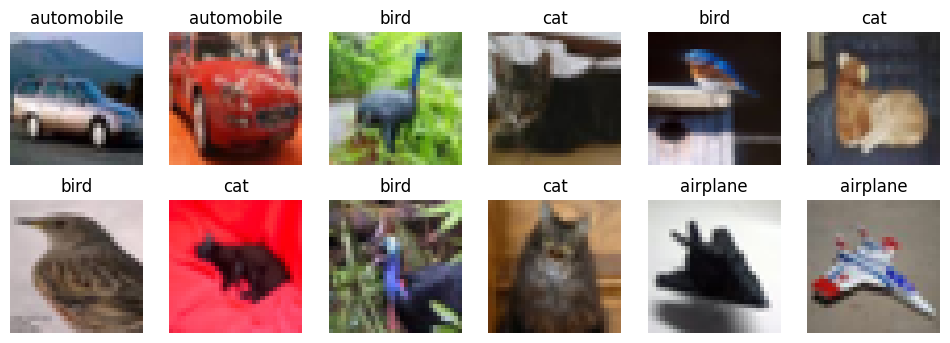

In [16]:
plt.figure(figsize=(12,4))
for i in range(12):
    plt.subplot(2,6,i+1)
    plt.imshow(X[i])
    plt.title(label_names[y[i]])
    plt.axis("off")
plt.show()


In [17]:
X_norm = X.astype("float32") / 255.0
# Aplatir pour K-means / PCA / LDA
X_flat = X_norm.reshape(len(X_norm), -1)
print(X_flat.shape)  # (20000, 3072)


(20000, 3072)


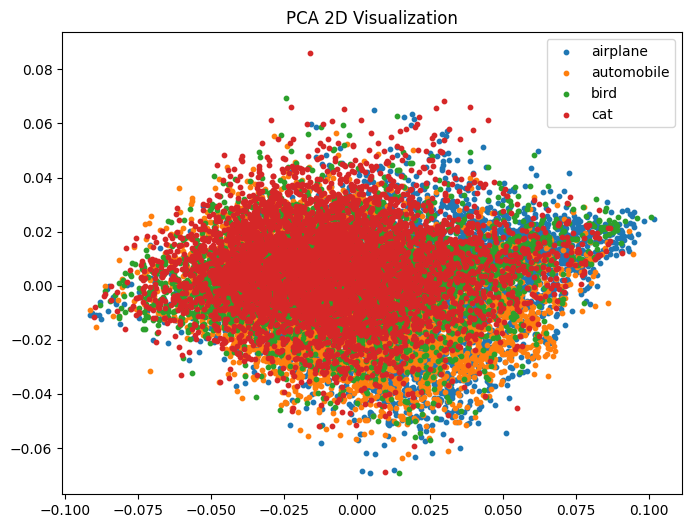

In [18]:
from sklearn.decomposition import PCA

pca2 = PCA(n_components=2)
X_pca2 = pca2.fit_transform(X_flat)

plt.figure(figsize=(8,6))
for label in range(4):
    plt.scatter(X_pca2[y==label,0], X_pca2[y==label,1], s=10, label=label_names[label])
plt.legend()
plt.title("PCA 2D Visualization")
plt.show()


In [19]:
from sklearn.cluster import KMeans

kmeans_raw = KMeans(n_clusters=4, random_state=0)
y_km_raw = kmeans_raw.fit_predict(X_flat)


C:\Users\DELL\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\cluster\_kmeans.py:1412: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  super()._check_params_vs_input(X, default_n_init=10)


In [32]:
pca95 = PCA(n_components=0.95)
X_pca95 = pca95.fit_transform(X_flat)

kmeans_pca95 = KMeans(n_clusters=4, random_state=0,n_init='auto')
y_km_pca95 = kmeans_pca95.fit_predict(X_pca95)


In [21]:
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis

lda = LinearDiscriminantAnalysis(n_components=3)
X_lda = lda.fit_transform(X_flat, y)

kmeans_lda = KMeans(n_clusters=4, random_state=0)
y_km_lda = kmeans_lda.fit_predict(X_lda)


C:\Users\DELL\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\cluster\_kmeans.py:1412: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  super()._check_params_vs_input(X, default_n_init=10)


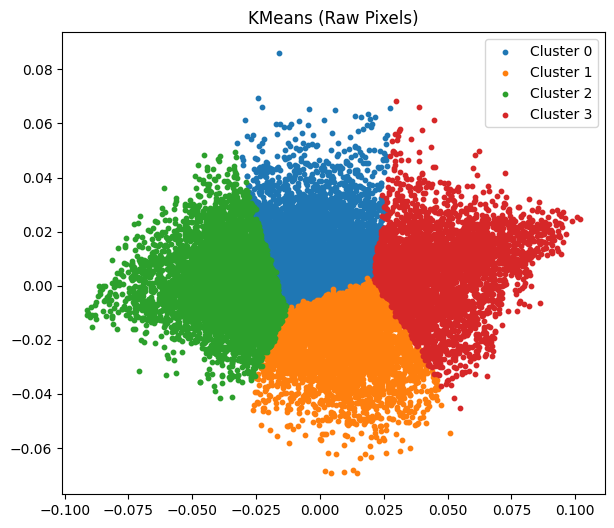

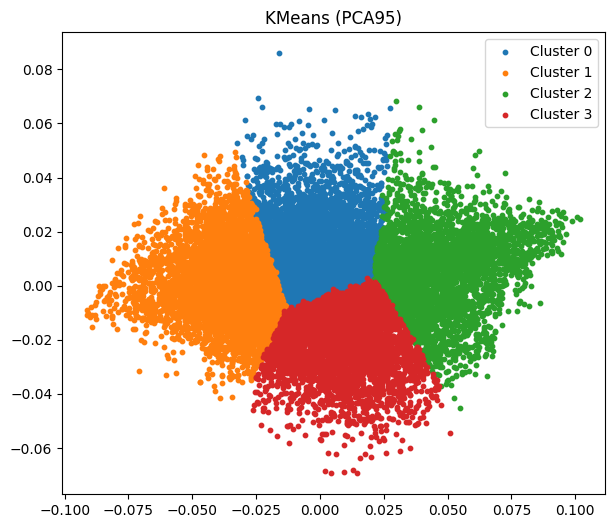

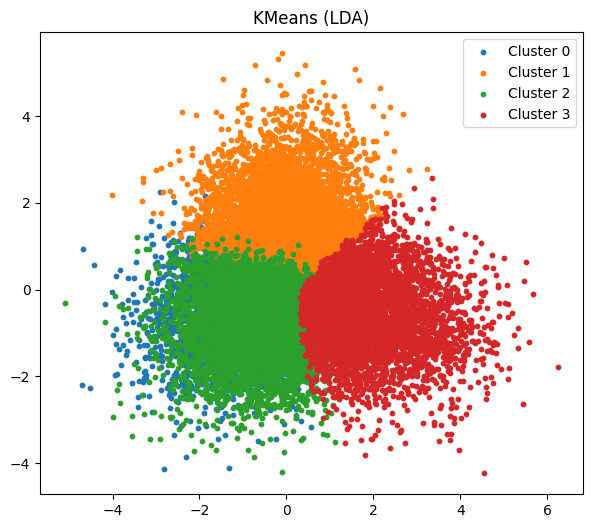

In [22]:
def plot_2d(Xfeat, clusters, title):
    Xproj = PCA(n_components=2).fit_transform(Xfeat)
    plt.figure(figsize=(7,6))
    for c in np.unique(clusters):
        plt.scatter(Xproj[clusters==c,0], Xproj[clusters==c,1], s=10, label=f"Cluster {c}")
    plt.title(title)
    plt.legend()
    plt.show()

plot_2d(X_flat, y_km_raw, "KMeans (Raw Pixels)")
plot_2d(X_pca95, y_km_pca95, "KMeans (PCA95)")
plot_2d(X_lda, y_km_lda, "KMeans (LDA)")


In [23]:
from sklearn.metrics import davies_bouldin_score

print("Davies-Bouldin Scores:")
print("Raw:", davies_bouldin_score(X_flat, y_km_raw))
print("PCA95:", davies_bouldin_score(X_pca95, y_km_pca95))
print("LDA:", davies_bouldin_score(X_lda, y_km_lda))


Davies-Bouldin Scores:
Raw: 2.451758318113329
PCA95: 2.356951711791761
LDA: 1.0625591432778747


In [24]:
from sklearn.metrics import confusion_matrix, classification_report
from scipy.optimize import linear_sum_assignment
import numpy as np

# mapping des clusters vers les vraies classes
def cluster_mapping(true, pred, k=4):
    cost = np.zeros((k,k))
    for i in range(k):
        for j in range(k):
            cost[i][j] = -np.sum((true==i) & (pred==j))
    row_ind, col_ind = linear_sum_assignment(cost)
    mapping = {col_ind[i]: row_ind[i] for i in range(k)}
    return np.array([mapping[p] for p in pred])

# evaluation
def evaluate_model(true, pred, name, class_names):
    pred_mapped = cluster_mapping(true, pred)
    print(f"=== {name} ===")
    print(confusion_matrix(true, pred_mapped))
    print(classification_report(true, pred_mapped, target_names=class_names))

# liste des noms des classes
class_names = ["airplane","automobile","bird","cat"]

# evaluation
evaluate_model(y, y_km_raw, "Raw Pixels", class_names)
evaluate_model(y, y_km_pca95, "PCA95", class_names)
evaluate_model(y, y_km_lda, "LDA", class_names)


=== Raw Pixels ===
[[1801 1436 1109  654]
 [ 567 1646 1072 1715]
 [ 822  682 1902 1594]
 [ 608  712 1915 1765]]
              precision    recall  f1-score   support

    airplane       0.47      0.36      0.41      5000
  automobile       0.37      0.33      0.35      5000
        bird       0.32      0.38      0.35      5000
         cat       0.31      0.35      0.33      5000

    accuracy                           0.36     20000
   macro avg       0.37      0.36      0.36     20000
weighted avg       0.37      0.36      0.36     20000

=== PCA95 ===
[[1801 1438 1108  653]
 [ 567 1652 1063 1718]
 [ 825  689 1890 1596]
 [ 610  720 1899 1771]]
              precision    recall  f1-score   support

    airplane       0.47      0.36      0.41      5000
  automobile       0.37      0.33      0.35      5000
        bird       0.32      0.38      0.34      5000
         cat       0.31      0.35      0.33      5000

    accuracy                           0.36     20000
   macro avg       0

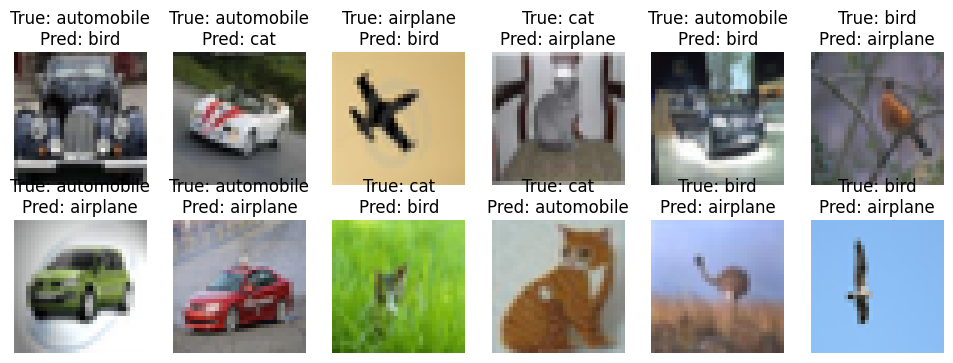

In [26]:
pred_best = cluster_mapping(y, y_km_lda) 
 
mis = np.where(pred_best != y)[0]          # indices des mauvaises prédictions

import random
sample = random.sample(list(mis), 12)

plt.figure(figsize=(12,4))
for i, idx in enumerate(sample):
    plt.subplot(2,6,i+1)
    plt.imshow(X[idx])
    plt.title(f"True: {label_names[y[idx]]}\nPred: {label_names[pred_best[idx]]}")
    plt.axis("off")
plt.show()


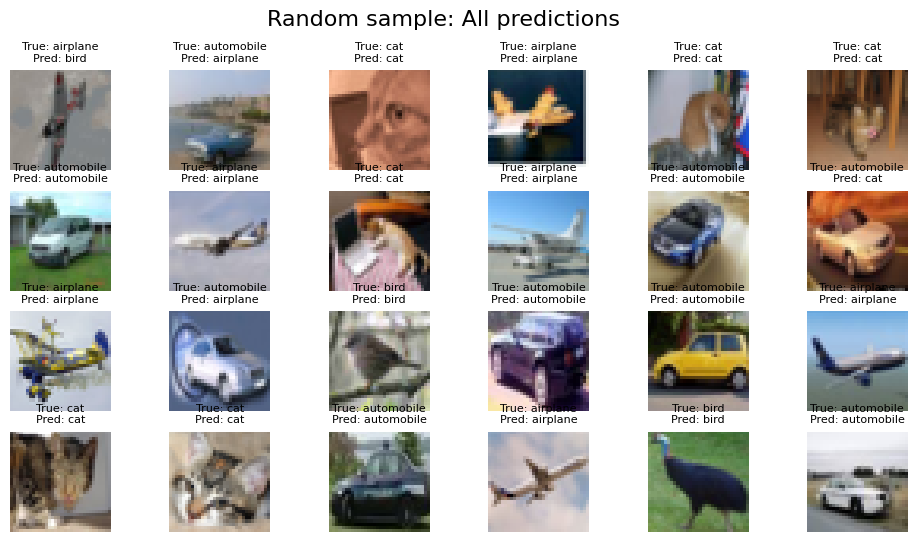

In [27]:
pred_best = cluster_mapping(y, y_km_lda)  # supposons LDA meilleur
num_images = 24  # combien d'images afficher
indices = np.random.choice(len(X), num_images, replace=False)

plt.figure(figsize=(12,6))
for i, idx in enumerate(indices):
    plt.subplot(4,6,i+1)
    plt.imshow(X[idx])
    plt.title(f"True: {label_names[y[idx]]}\nPred: {label_names[pred_best[idx]]}", fontsize=8)
    plt.axis("off")
plt.suptitle("Random sample: All predictions", fontsize=16)
plt.show()


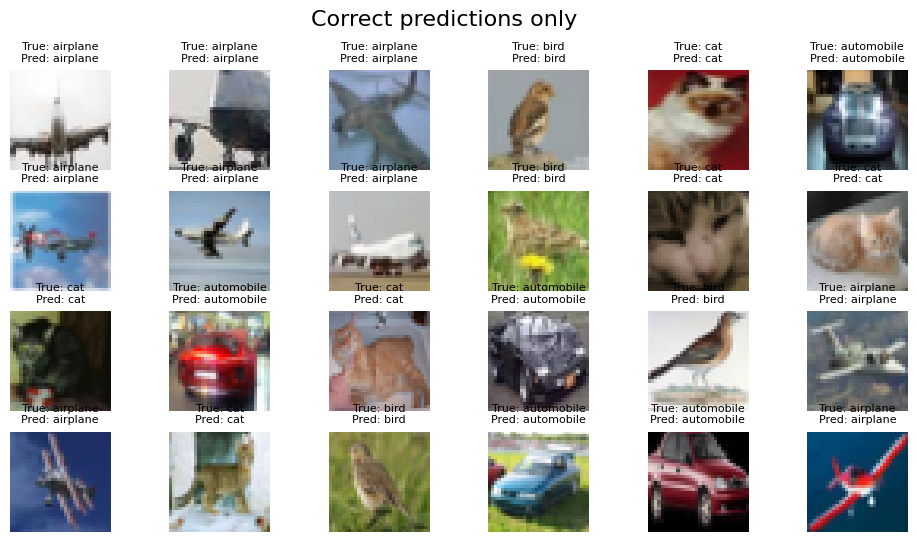

In [28]:
correct = np.where(pred_best == y)[0]  # indices des bonnes prédictions
num_images = min(24, len(correct))
indices = np.random.choice(correct, num_images, replace=False)

plt.figure(figsize=(12,6))
for i, idx in enumerate(indices):
    plt.subplot(4,6,i+1)
    plt.imshow(X[idx])
    plt.title(f"True: {label_names[y[idx]]}\nPred: {label_names[pred_best[idx]]}", fontsize=8)
    plt.axis("off")
plt.suptitle("Correct predictions only", fontsize=16)
plt.show()


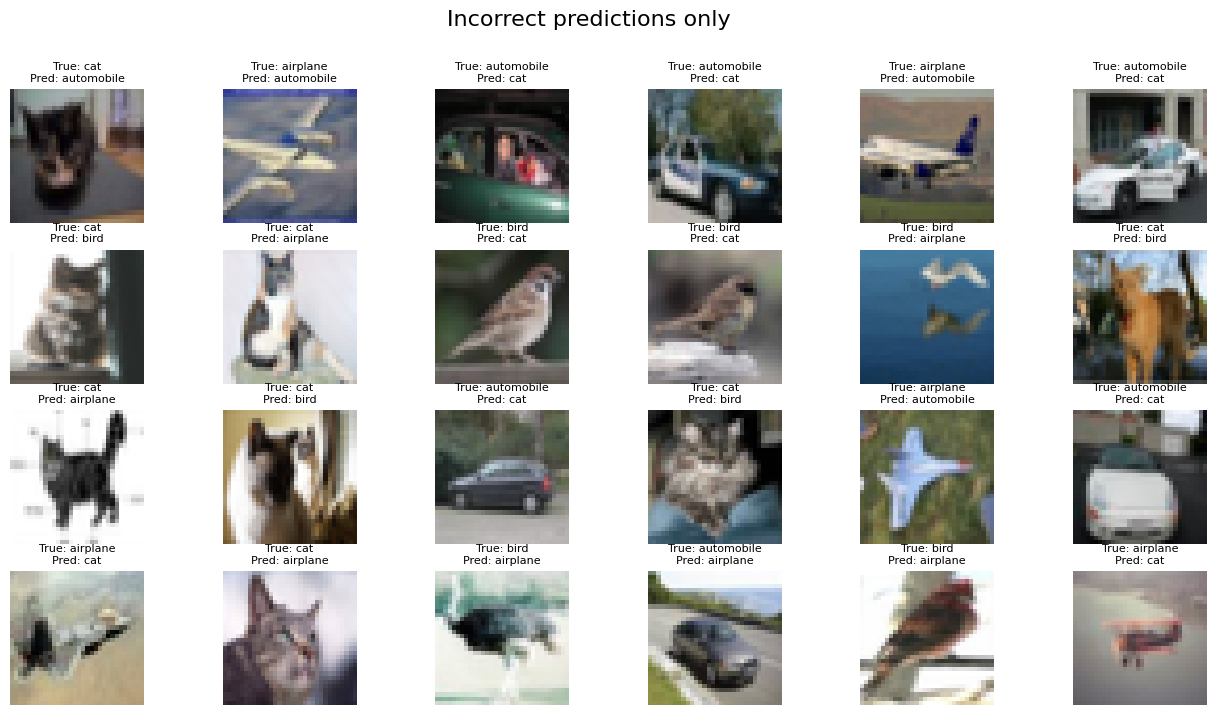

In [29]:
incorrect = np.where(pred_best != y)[0]  # indices des mauvaises prédictions
num_images = min(24, len(incorrect))
indices = np.random.choice(incorrect, num_images, replace=False)

plt.figure(figsize=(16,8))
for i, idx in enumerate(indices):
    plt.subplot(4,6,i+1)
    plt.imshow(X[idx], interpolation='nearest')

    plt.title(f"True: {label_names[y[idx]]}\nPred: {label_names[pred_best[idx]]}", fontsize=8)
    plt.axis("off")
plt.suptitle("Incorrect predictions only", fontsize=16)
plt.show()


In [30]:
from sklearn.decomposition import PCA
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import confusion_matrix, classification_report, davies_bouldin_score

# 1. PCA pour réduire bruit
pca95 = PCA(n_components=0.95)
X_pca95 = pca95.fit_transform(X_flat)

# 2. LDA pour séparation classes
lda = LinearDiscriminantAnalysis(n_components=3)
X_lda = lda.fit_transform(X_pca95, y)

# 3. Scaling
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_lda)

# 4. KMeans
kmeans = KMeans(n_clusters=4, random_state=0)
y_km = kmeans.fit_predict(X_scaled)
pred_best = cluster_mapping(y, y_km)


C:\Users\DELL\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\cluster\_kmeans.py:1412: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  super()._check_params_vs_input(X, default_n_init=10)


In [33]:
from sklearn.metrics import confusion_matrix, classification_report, davies_bouldin_score

# Noms des classes
class_names = ["airplane","automobile","bird","cat"]

# 1. Davies-Bouldin Score
db_score = davies_bouldin_score(X_scaled, y_km)
print("Davies-Bouldin Score LDA + PCA:", db_score)

# 2. Confusion matrix
cm = confusion_matrix(y, pred_best)
print("Confusion Matrix:\n", cm)

# 3. Classification report
report = classification_report(y, pred_best, target_names=class_names)
print("Classification Report:\n", report)


Davies-Bouldin Score LDA + PCA: 1.0529757595809244
Confusion Matrix:
 [[3598  430  314  658]
 [ 620 3337  319  724]
 [ 866  277 2490 1367]
 [ 425  450  738 3387]]
Classification Report:
               precision    recall  f1-score   support

    airplane       0.65      0.72      0.68      5000
  automobile       0.74      0.67      0.70      5000
        bird       0.64      0.50      0.56      5000
         cat       0.55      0.68      0.61      5000

    accuracy                           0.64     20000
   macro avg       0.65      0.64      0.64     20000
weighted avg       0.65      0.64      0.64     20000



In [34]:
from sklearn.metrics import davies_bouldin_score

print("Davies-Bouldin Scores:")
print("Raw:", davies_bouldin_score(X_flat, y_km_raw))
print("PCA95:", davies_bouldin_score(X_pca95, y_km_pca95))
print("LDA:", davies_bouldin_score(X_lda, y_km_lda))



Davies-Bouldin Scores:
Raw: 2.451758318113329
PCA95: 2.356951711791761
LDA: 1.4486095248834103
